In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [10]:
df = pd.read_csv("billing_data_10_lakh.csv")

In [11]:
df.shape

(1000000, 4)

In [12]:
df.columns

Index(['SKU', 'Billing_Date', 'Billing_Quantity', 'Customer_ID'], dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   SKU               1000000 non-null  object
 1   Billing_Date      1000000 non-null  object
 2   Billing_Quantity  1000000 non-null  int64 
 3   Customer_ID       1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [14]:
df.describe()

,Billing_Quantity
count,1000000.000000
mean,50.480890
std,28.868872
min,1.000000
25%,25.000000
50%,50.000000
75%,75.000000
max,100.000000


In [15]:
df.isnull().sum()

SKU                 0
Billing_Date        0
Billing_Quantity    0
Customer_ID         0
dtype: int64

In [16]:
df["Customer_ID"].nunique()

2000

In [17]:
df["SKU"].nunique()

11232

In [18]:
df["Billing_Date"] = pd.to_datetime(df["Billing_Date"])

In [19]:
df["Year"] = df["Billing_Date"].dt.year
df["Month"] = df["Billing_Date"].dt.month

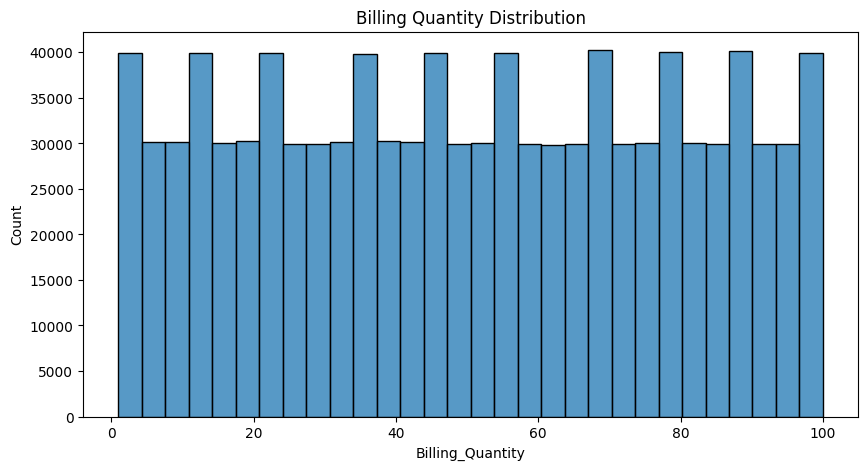

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df["Billing_Quantity"], bins=30)
plt.title("Billing Quantity Distribution")
plt.show()

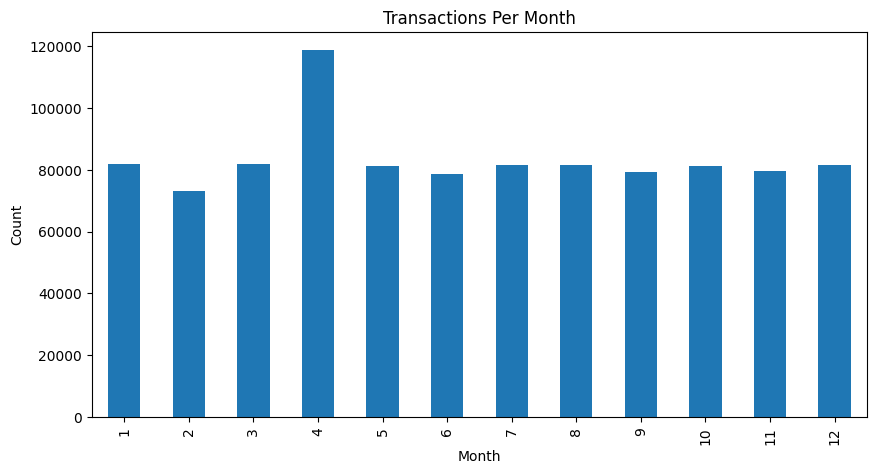

In [21]:
monthly_sales = df.groupby("Month").size()

monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("Transactions Per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

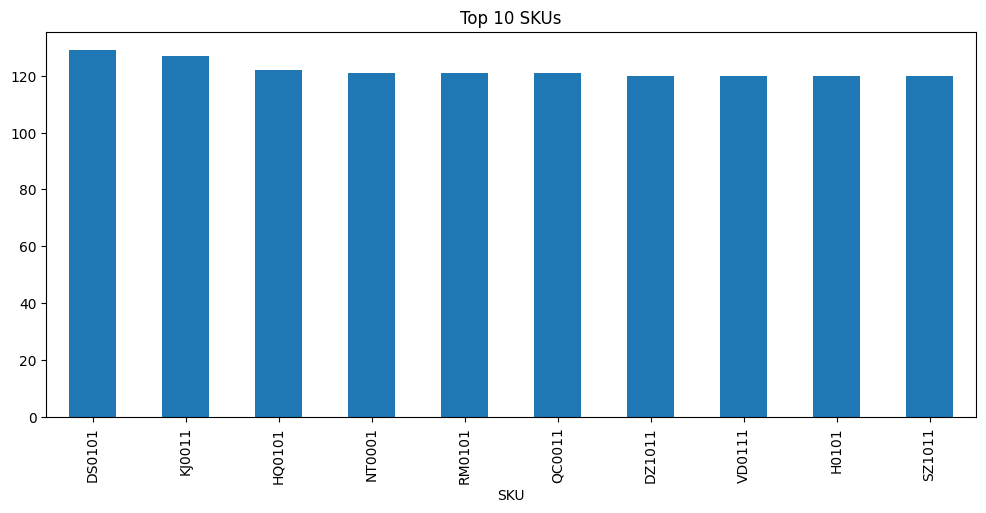

In [22]:
top_skus = df["SKU"].value_counts().head(10)

top_skus.plot(kind="bar", figsize=(12,5))
plt.title("Top 10 SKUs")
plt.show()

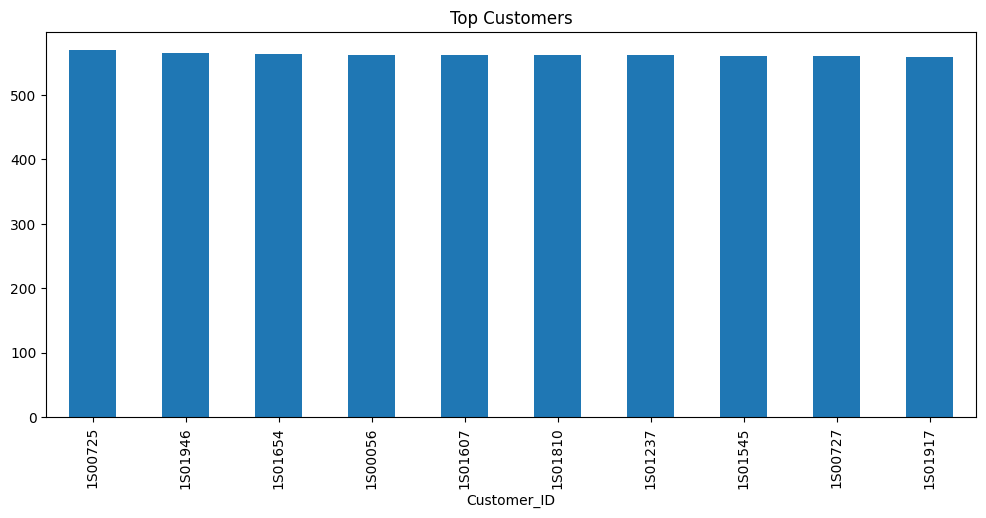

In [23]:
top_customers = df["Customer_ID"].value_counts().head(10)

top_customers.plot(kind="bar", figsize=(12,5))
plt.title("Top Customers")
plt.show()

In [24]:
df["Price"] = np.random.randint(100, 5000, size=len(df))

df["Revenue"] = df["Price"] * df["Billing_Quantity"]

In [25]:
df["Revenue"].sum()

np.int64(128690015388)

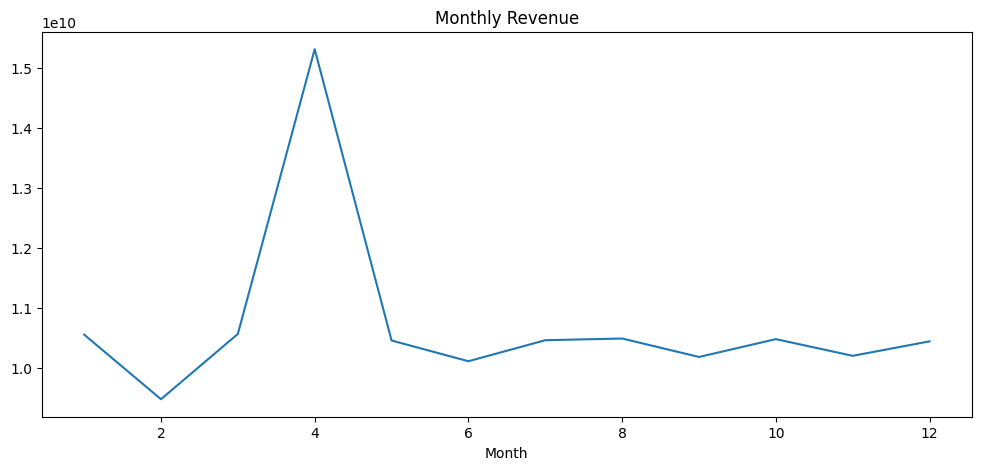

In [26]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(kind="line", figsize=(12,5))
plt.title("Monthly Revenue")
plt.show()

In [27]:
df.to_csv("processed_billing_data.csv", index=False)